# Методы запросов в протоколе **HTTP**

Для того чтобы указать серверу на то, какое действие мы хотим произвести с ресурсом, в протоколе HTTP используются так называемые методы. В HTTP существует несколько методов, которые описывают действия с ресурсами. Чаще всего используются **GET и POST**.

##### Клиент и сервер взаимодействуют между собой, обмениваясь **одиночными сообщениями (не потоком данных)** посредством сетевых протоколов, которые формализуют общение между ними. В настоящее время повсеместно используемый протокол в интернете, позволяющий клиенту получать различные ресурсы **(например, HTML-документы)**, — это протокол HTTP.

### **GET** — получение ресурса

* **Метод GET** запрашивает информацию из указанного источника и не может влиять на его содержимое. Запрос доступен для кэширования данных (то есть для сохранения, восстановления и дальнейшего использования) и добавления в закладки. **Длина запроса ограничена (максимальная длина — 2048 символов)**.

* **Пример GET-запроса**, отправляемого через адресную строку браузера: 

In [ ]:
# ПРИМЕР
 http://site.ru/page.php?name=dima&age=27

### **POST** — создание ресурса

* **Метод POST** используется для отправки данных, которые могут оказывать влияние на содержимое ресурса. В отличие от метода GET, запросы POST не могут быть кэшированы, они не остаются в истории браузера и их нельзя добавить в закладки. **Длина запроса POST не ограничивается**.

* **Пример POST-запроса**, отправляемого через форму запроса:

In [ ]:
# ПРИМЕР:

POST / HTTP/1.0\r\n
Host: www.site.ru\r\n
Referer: http://www.site.ru/index.html\r\n
Cookie: income=1\r\n
Content-Type: application/x-www-form-urlencoded\r\n
Content-Length: 35\r\n
\r\n
login=Dima&password=12345

### ✍ В стандартной библиотеке Python **для отправки веб-запросов существует** функция urllib2, но большинство разработчиков используют стороннюю библиотеку **requests** (c англ. запросы), потому что её работа более стабильна, а созданный с её помощью код получается проще.

Перед началом работы библиотеку requests потребуется установить. Например, в Jupyter Notebook это делается с помощью такой команды:

In [ ]:
# Устанавливаем библиотеку requests
# pip install requests 

Как только библиотека установлена, **импортируем** её и отправим наш первый запрос к ресурсу **Курсы валют ЦБ РФ в XML и JSON**. Используем **метод get()** из библиотеки requests, передав ему соответствующий **URL —  https://www.cbr-xml-daily.ru/daily_json.js**:

In [2]:
import requests # Импортируем библиотеку requests
url = 'https://www.cbr-xml-daily.ru/daily_json.js' # Определяем значение URL страницы для запроса
response = requests.get(url) # Делаем GET-запрос к ресурсу и результат ответа сохраняем в переменной response

In [2]:
print (response)

<Response [200]>


In [3]:
# Варинт 2

response = requests.get('https://www.cbr-xml-daily.ru/daily_json.js')
print (response)

<Response [200]>


##### **Вывод:** Мы получили объект ответа Response, который содержит всю нужную нам информацию. По умолчанию в квадратных скобках на экран выводится код статуса ответа. В данном случае он равен **200** — то есть запрос был корректным и сервер отдал нам нужную информацию. Значение кода статуса **404** означало бы, что страница по указанному адресу не найдена, а значение **403** — что синтаксис GET-запроса неверный.

Код ответа в виде числовой переменной можно получить с помощью метода **status_code**:

In [4]:
print(response.status_code) # Выводим числовое значение response на экран

200


##### Сформируем запрос для **XML** через GET-запрос к ресурсу https://www.cbr-xml-daily.ru/daily.xml

In [10]:
response = requests.get('https://www.cbr-xml-daily.ru/daily.xml')
print (response)

<Response [200]>


### **Работаем с ответом**

Текст ответа хранится в атрибуте text. Выведем значение атрибута на экран и посмотрим на его содержимое:

In [5]:
# !!!!!!   ВАЖНО   !!!!!!  формат переменной response - JSON 
#print (type(response))
print(response.text) # Выводим содержимое атрибута text переменной response на экран

{
    "Date": "2025-04-22T11:30:00+03:00",
    "PreviousDate": "2025-04-19T11:30:00+03:00",
    "PreviousURL": "\/\/www.cbr-xml-daily.ru\/archive\/2025\/04\/19\/daily_json.js",
    "Timestamp": "2025-04-21T20:00:00+03:00",
    "Valute": {
        "AUD": {
            "ID": "R01010",
            "NumCode": "036",
            "CharCode": "AUD",
            "Nominal": 1,
            "Name": "Австралийский доллар",
            "Value": 51.2097,
            "Previous": 51.449
        },
        "AZN": {
            "ID": "R01020A",
            "NumCode": "944",
            "CharCode": "AZN",
            "Nominal": 1,
            "Name": "Азербайджанский манат",
            "Value": 47.5057,
            "Previous": 47.7277
        },
        "GBP": {
            "ID": "R01035",
            "NumCode": "826",
            "CharCode": "GBP",
            "Nominal": 1,
            "Name": "Фунт стерлингов",
            "Value": 107.0631,
            "Previous": 107.5635
        },
        "AMD": {

### Для того чтобы удобно было работать с полученной информацией, нам необходимо преобразовать строку в словарь. В объект ответа Response  из библиотеки requests уже встроен метод **json()** .

* Импортируем функцию **pprint()**, применим к полученному ответу **метод json()** и выведем полученный результат на экран:

In [4]:
import json # Импортируем модуль json
from pprint import pprint # Импортируем функцию pprint()

currencies = response.json() # Применяем метод json()
pprint(currencies) # Выводим результат на экран

{'Date': '2025-04-24T11:30:00+03:00',
 'PreviousDate': '2025-04-23T11:30:00+03:00',
 'PreviousURL': '//www.cbr-xml-daily.ru/archive/2025/04/23/daily_json.js',
 'Timestamp': '2025-04-23T20:00:00+03:00',
 'Valute': {'AED': {'CharCode': 'AED',
                    'ID': 'R01230',
                    'Name': 'Дирхам ОАЭ',
                    'Nominal': 1,
                    'NumCode': '784',
                    'Previous': 22.1816,
                    'Value': 22.4271},
            'AMD': {'CharCode': 'AMD',
                    'ID': 'R01060',
                    'Name': 'Армянских драмов',
                    'Nominal': 100,
                    'NumCode': '051',
                    'Previous': 20.8807,
                    'Value': 21.1428},
            'AUD': {'CharCode': 'AUD',
                    'ID': 'R01010',
                    'Name': 'Австралийский доллар',
                    'Nominal': 1,
                    'NumCode': '036',
                    'Previous': 52.4371,
            

### **Вывод:** Теперь данные находятся в словаре и можно легко получать необходимые значения.

* Например, по ключу **Valute** мы можем обратиться к вложенному словарю, который содержит информацию о мировых валютах. Выведем на экран, например, информацию о евро **(USD)**: 

In [9]:
pprint(currencies['Valute']['USD']) # Выводим на экран информацию о валюте Австралийский доллар

{'CharCode': 'USD',
 'ID': 'R01235',
 'Name': 'Доллар США',
 'Nominal': 1,
 'NumCode': '840',
 'Previous': 81.1371,
 'Value': 80.7597}


In [10]:
pprint(currencies['Valute']['USD']['ID'])

'R01235'


In [11]:
print(currencies['Valute']['CZK']['Name'])

Чешских крон


# **Основы HTML**

* **HTML** (англ. HyperText Markup Language, рус. язык гипертекстовой разметки) — стандартизированный язык разметки документов в интернете. Большинство веб-страниц содержат описание разметки на языке HTML. Язык HTML интерпретируется браузерами. Полученный в результате интерпретации текст отображается на экране монитора компьютера или мобильного устройства.

### **HTML** является близким родственником уже знакомого вам **формата XML**. Разметка на языке HTML делается с помощью так называемых тегов, которые помещаются в угловые скобки, и применяется к элементам, заключённым внутри них. Посмотрите на примеры:

<h2> Это заголовок второго уровня </h2>
<div> А это обычный текст </div>

смотри пример ниже по тексту:

<h2> Это заголовок второго уровня </h2>
<div> А это обычный текст </div>

In [ ]:
# У корректной HTML-страницы есть заголовок и тело страницы. 
# В заголовке (в тегах <head> … </head>)  размещается техническая информация, подключаются скрипты и стили. 
# В теле <body> … </body> находятся текст и данные, которые непосредственно отображаются на странице в браузере.

Разметка небольшой страницы выглядит примерно так:

<!DOCTYPE html>
<html lang="ru">
    <head>
        <title>Название страницы</title>
        <meta charset="UTF-8">
    </head>
    <body>
        <h1> Это заголовок страницы </h1>
        <p> Какой-то текст </p>
    </body>
</html>

* Вы можете сохранить этот код в текстовом файле с расширением .html и открыть этот файл в браузере.

<!DOCTYPE html>
<html lang="ru">
    <head>
        <title>Название страницы</title>
        <meta charset="UTF-8">
    </head>
    <body>
        <h1> Это заголовок страницы </h1>
        <p> Какой-то текст </p>
    </body>
</html>

In [ ]:
# Обратите внимание, что теги образуют иерархическую структуру, то есть одни теги расположены внутри других. 
# В примере выше тег <p> … </p> находится внутри тега <body> … </body>.

##### Кроме того, у тегов могут быть атрибуты, которые пишутся внутри открывающегося тега. Самые популярные атрибуты — это **class** и **id**:


<h1 id="big-title"> Заголовок страницы </h1>
<p class="red-back"> Какой-то текст </p>

<h1 id="big-title"> Заголовок страницы </h1>
<p class="red-back"> Какой-то текст </p>

## Изучение языка HTML находится вне рамок этого курса, но для того, чтобы собирать информацию с веб-страниц, нет необходимости хорошо знать HTML. Достаточно понимать, что:

* существуют теги с разными именами;
* у тегов бывают атрибуты, такие как class и id;
* теги образуют иерархическую структуру, то есть одни теги вложены в другие.

### **Получаем содержимое веб-страницы**

* Получим **HTML-код** интересующей нас страницы.

In [5]:
import requests # Импортируем библиотеку requests
url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url)  # Выполняем GET-запрос
print(response.text)  # Выводим содержимое атрибута text

<!DOCTYPE html>
<html prefix="og: http://ogp.me/ns#" lang="ru">
<head>
  <meta charset="utf-8">
  <meta name="viewport" content="width=device-width, initial-scale=1">
  <title>Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей</title>
    <link rel="preload" href="https://staticn1.nplus1.ru/fonts/AeonikPro/AeonikPro-Regular.woff2" as="font" type="font/woff2" crossorigin />
    <link rel="preload" href="https://staticn1.nplus1.ru/fonts/Spectral/Spectral-Regular.woff" as="font" type="font/woff2" crossorigin />
  <link href="/front-build/css/main.css?id=842e64708435127ee441c2e86afffea2" rel="stylesheet">
  <link href="/front-build/css/app.css?id=92673ebe7185ebc42e29fc7294a4c65f" rel="stylesheet">
  

  <link rel="apple-touch-icon" sizes="180x180" href="/apple-touch-icon.png">
  <link rel="icon" type="image/png" sizes="32x32" href="/favicon-32x32.png">
  <link rel="icon" type="image/png" sizes="16x16" href="/favicon-16x16.png">
  <link rel="

##### В отличие от предыдущего примера, где ответ возвращался в **JSON-формате**, мы не можем так просто преобразовать **HTML-код** в словарь и извлечь необходимую нам информацию.

### ✍ Для поиска необходимых нам данных мы будем использовать **библиотеку BeautifulSoup**, которая позволяет по названию тегов и их атрибутов получать содержащийся в них текст.

* **BeautifulSoup** не является частью стандартной библиотеки, поэтому для начала её нужно установить. Например, в Jupyter Notebook это делается с помощью такой команды:

In [2]:
# Устанавливаем библиотеку BeautifulSoup
# pip install beautifulsoup4 

* После установки импортируем библиотеку в наш код:

In [3]:
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

* Теперь мы можем извлекать данные из **любой веб-страницы**

* Ранее мы уже получили содержимое страницы с помощью GET-запроса и сохранили информацию в переменной **response** , теперь создадим **объект BeautifulSoup с именем page**, указывая в качестве параметра **html.parser**.

* Для примера получим информацию o **title** (с англ. заголовок) — это строка, которая отображается на вкладке браузера:

In [6]:
import requests # Импортируем библиотеку requests
from bs4 import BeautifulSoup # Импортируем библиотеку BeautifulSoup

url = 'https://nplus1.ru/news/2021/10/11/econobel2021' # Определяем адрес страницы
response = requests.get(url) # Выполняем GET-запрос, содержимое ответа присваивается переменной response
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup, указывая html-парсер

print(page.title) # Получаем тег title, отображающийся на вкладке браузера
print ('------------------------------------')
print(page.title.text) # Выводим текст из полученного тега, который содержится в атрибуте text

<title>Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей</title>
------------------------------------
Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей


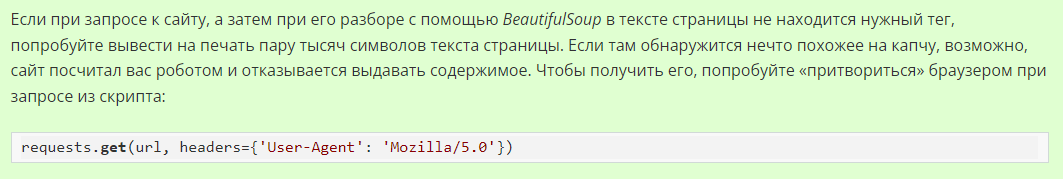

### **Извлекаем заголовок статьи**

* Выполним поставленную ранее задачу: получить информацию о странице и извлечь **заголовок статьи**, опубликованной на этой странице, **дату публикации**, а также **текст статьи**.

In [ ]:
# 1. Предположим, что мы знаем, что в HTML-коде рассматриваемой нами страницы заголовок статьи заключён в тег <h1> … </h1># (заголовок первого уровня).

# 2. Тогда мы можем получить его текст с помощью метода find() (с англ. найти) объекта BeautifulSoup, передав ему название интересующего нас тега:

In [15]:
# Применяем метод find() к объекту и выводим результат на экран
print(page.find('h1').text) 


            Премию Нобеля по экономике присудили за исследования экономики труда и причинно-следственных связей
          


### Но как же узнать, в каких именно тегах заключена необходимая информация?

* Проще всего это сделать с помощью так называемого инструмента разработчика, который есть во всех современных браузерах. Покажем, как открыть данный инструмент на примере использования браузера Google Chrome.

* **Устанавливаем курсор на элементе страницы** (заголовок статьи), информацию о котором хотим получить, нажимаем на правую клавишу мыши и в выпадающем списке выбираем пункт **«Просмотреть код элемента»** или **«Исследовать»** в зависимости от браузера.

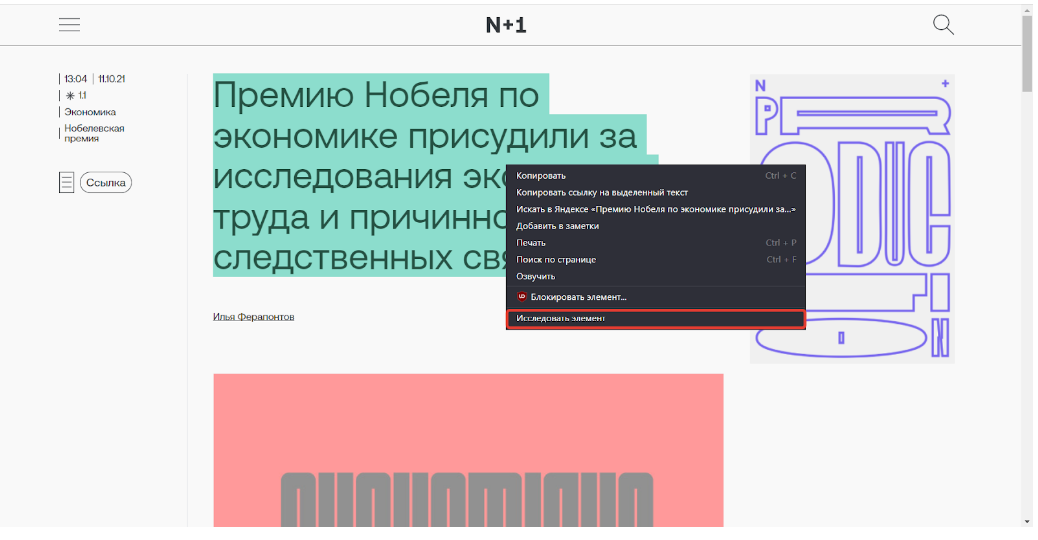

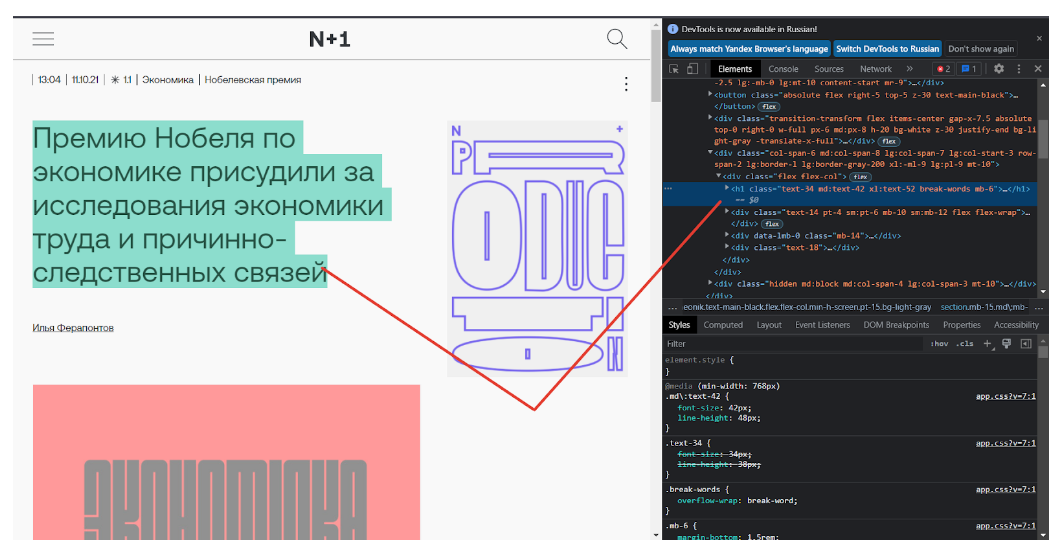

In [5]:
# ЗАДАЧА: 
# Напишите функцию wiki_header, которая по адресу страницы возвращает заголовок первого уровня для статей на Wikipedia.


import requests
from bs4 import BeautifulSoup

def wiki_header(url):
    response = requests.get(url)
    page = BeautifulSoup(response.text, 'html.parser')
    return print (page.h1.text)

z = wiki_header('https://en.wikipedia.org/wiki/Operating_system') # или просто без z - wiki_header('https://en.wikipedia.org/wiki/Operating_system') 


Operating system


In [ ]:
# ЭТАЛОННОЕ РЕШЕНИЕ

def wiki_header(url):
    page=BeautifulSoup(requests.get(url).text,'html.parser') # !!!!!!!!!!!!   ВАЖНО   !!!!!!!!!!! - все в одну строку
    header=page.find('h1').text
    return header

### **Неуникальные теги**: извлекаем текст и дату публикации статьи

##### Теперь получим сам текст статьи. Как вы уже знаете, первым делом необходимо определить, в какой тег он заключён. Применим, как и ранее, инструмент разработчика.

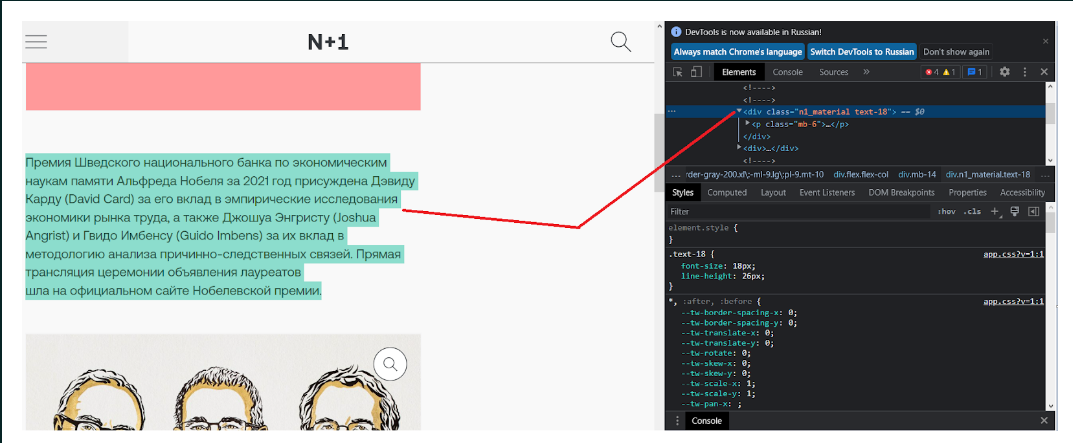

In [39]:
print(page.find('div').text) # Выводим содержимое атрибута text тега div

##### **Вывод:** мы увидели не то, что ожидали — кучу текста, не имеющего отношения к тому, что мы искали...

* В чём же проблема?

* Дело в том, что **теги <div … /div>** очень распространённые и на странице их очень много. **Метод find()** нашёл первый из них, но это не то, что нам надо.

##### Посмотрим на нашу страницу, используя инструмент разработчика, ещё раз. Можем заметить, что у искомого текста есть свой класс — **n1_material text-18** :

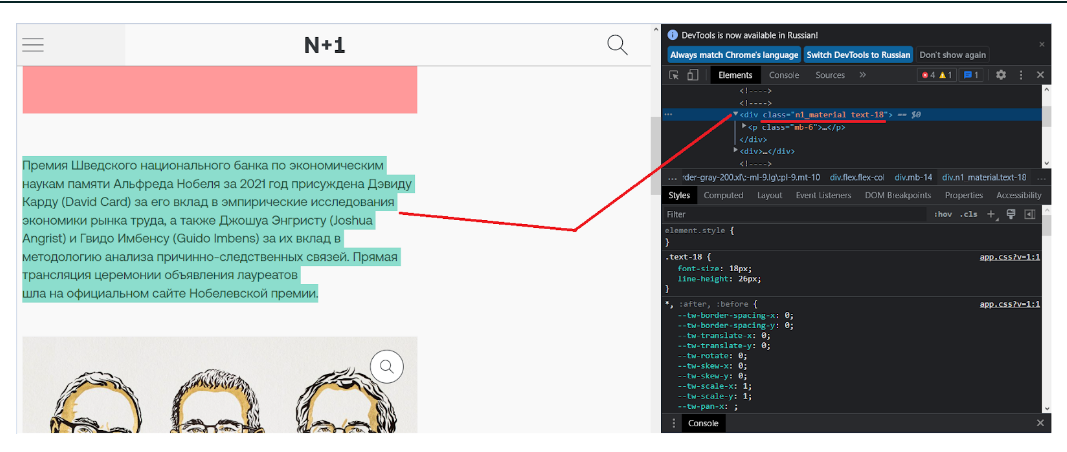

### Передадим название класса в метод **find()** с помощью **аргумента class_** и получим текст статьи:

In [17]:
print(page.find('div', class_='n1_material text-18').text) # Выводим содержимое атрибута text тега div класса n1_material text-18
print ('---------------------------------------------------')
pprint(page.find('div', class_='n1_material text-18').text)

Премия Шведского национального банка по экономическим наукам памяти Альфреда Нобеля за 2021 год присуждена Дэвиду Карду (David Card) за его вклад в эмпирические исследования экономики рынка труда, а также Джошуа Энгристу (Joshua Angrist) и Гвидо Имбенсу (Guido Imbens) за их вклад в методологию анализа причинно-следственных связей. Прямая трансляция церемонии объявления лауреатов шла на официальном сайте Нобелевской премии.
---------------------------------------------------
('Премия Шведского национального банка по\xa0экономическим наукам памяти '
 'Альфреда Нобеля за\xa02021 год присуждена Дэвиду Карду (David Card) за его '
 'вклад в эмпирические исследования экономики рынка труда, а также Джошуа '
 'Энгристу (Joshua Angrist) и Гвидо Имбенсу (Guido Imbens) за их вклад в '
 'методологию анализа причинно-следственных связей. Прямая трансляция '
 'церемонии объявления лауреатов шла\xa0на\xa0официальном сайте Нобелевской '
 'премии.')


### В данном случае происходит поиск точного строкового значения **class атрибута**, т. е. выполнение строк кода:

* print(page.find('div', class_='n1_material').text)
* print(page.find('div', class_='n1_material text-18').text)

* **даст одинаковый результат**.

### При выполнении строки кода

* print(page.find('div', class_='text-18 n1_material').text)

**мы получим ошибку**, так как такого строкового значения в области поиска нет.

### Аналогично получим информации о теге, который содержит **дату написания статьи**, отображаемую в левом верхнем углу страницы.

* Итак, нам нужен **тег <a … /a>** с классом **"relative before:block before:w-px before:bg-current before:h-4 before:absolute before:left-0 group pl-2 flex inline-flex items-center". Для поиска достаточно указать в качестве класса "relative"**, отбросив дополнительные настройки.

In [6]:
# Выводим на экран содержимое атрибута text тега a с классом "relative"
print(page.find('a', class_= "relative").text)


11.10.21



### **Сбор нескольких элементов: собираем все ссылки на странице**

* Рассмотрим ещё один сценарий: вы хотите собрать сразу несколько элементов со страницы. Например, представьте, что вы хотите получить названия всех языков программирования, упомянутых на странице в Wikipedia в статье про языки программирования.

* Можно заметить, что все названия языков программирования на этой странице связаны ссылками c соответствующими статьями о них. Таким образом, нам необходимо собрать все ссылки на странице. Для ссылок в HTML предусмотрен **тег <a … /a>**. Попробуем использовать find():

In [19]:
url = 'https://en.wikipedia.org/wiki/List_of_programming_languages' # Задаём адрес ресурса
response = requests.get(url) # Делаем GET-запрос к ресурсу
page = BeautifulSoup(response.text, 'html.parser') # Создаём объект BeautifulSoup

print(page.find('a').text) # Ищем ссылку по тегу <a> и выводим её на экран

Jump to content


##### **ИТОГ:** Мы получили только одну ссылку, хотя на странице их явно больше.

##### Это происходит, потому что **метод find()** возвращает только первый подходящий элемент. Если требуется получить больше элементов, необходимо воспользоваться **методом find_all()** (с англ. найти все):

In [20]:
links = page.find_all('a') # Ищем все ссылки на странице и сохраняем в переменной links в виде списка
print(len(links)) # Выводим количество найденных ссылок

966


Итак, на данный момент в этих учебных материалов на странице содержится 967 ссылок. Посмотрим на некоторые из них:

In [22]:
print([link.text for link in links[500:510]]) # Выводим ссылки с 500 по 509 включительно

['Magik', 'Magma', 'Maple', 'MAPPER', 'MARK-IV', 'Mary', 'MATLAB', 'MASM Microsoft Assembly x86', 'MATH-MATIC', 'Maude system']


In [21]:
print([link.text for link in links[0:10]]) # Выводим ссылки с 1 по 9 включительно

['Jump to content', 'Main page', 'Contents', 'Current events', 'Random article', 'About Wikipedia', 'Contact us', 'Help', 'Learn to edit', 'Community portal']


* Не все ссылки соответствуют названиям языков программирования — страница содержит также «служебные» ссылки, такие, например, как **Jump to navigation** (с англ. Перейти к навигации) или **Alphabetical** (с англ. По алфавиту):

In [24]:
print(links[0:2]) # можно конечно и так, но не удобно - выводится много технической информации

[<a class="mw-jump-link" href="#bodyContent">Jump to content</a>, <a accesskey="z" href="/wiki/Main_Page" title="Visit the main page [z]"><span>Main page</span></a>]


### **API** — это специальные разделы сайта, где информацию можно получать без разметки, а формат запросов и ответов зафиксирован. API созданы для того, чтобы облегчить взаимодействие с сайтом для сторонних разработчиков.

* К примеру, мы уже видели, как ресурс **Курсы валют ЦБ РФ в XML и JSON** возвращает данные о валютах в **JSON-формате**. Это пример API.

### **Ключ авторизации**

* Для того чтобы начать работать с API, обычно необходимо получить сервисный ключ авторизации — **токен**.

* **Токен** — это средство идентификации пользователя или отдельного сеанса работы в компьютерных сетях и приложениях. Различают **программные** и **аппаратные** токены.
* Мы будем использовать программный токен, который обычно представляет собой зашифрованную последовательность символов, позволяющую точно идентифицировать объект и определить уровень его привилегий. Он генерируется системой авторизации и привязывается к конкретному сеансу работы, клиенту сети или пакету данных.

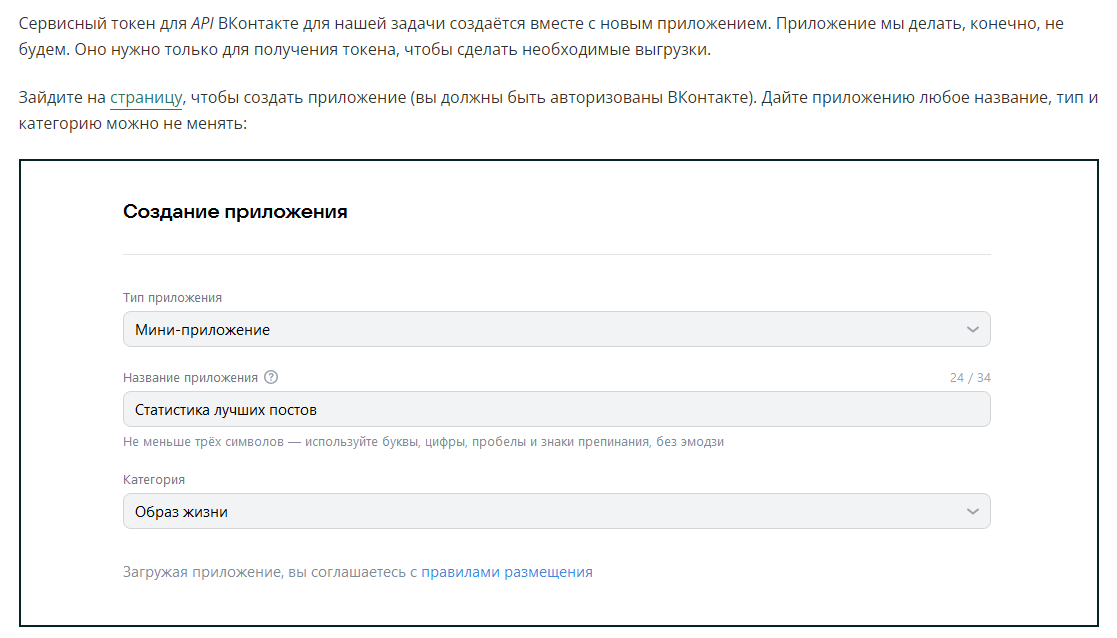

##### Подтвердив создание приложения на сайте в приложении ВКонтакте или по СМС, выберите на панели слева раздел **Разработка** и откройте **Ключи доступа**. Нужный нам токен лежит в поле **Сервисный ключ**:

### **Первые запросы к API**

* Сначала рассмотрим работу API на простом примере, на основе которого работают многие системы.

* Сделаем наш первый запрос из **браузера**.

* Перейдите по следующей ниже ссылке в браузере, подставив вместо слова **TOKEN** ваш персональный **сервисный ключ доступа (токен)**, полученный на предыдущем шаге:

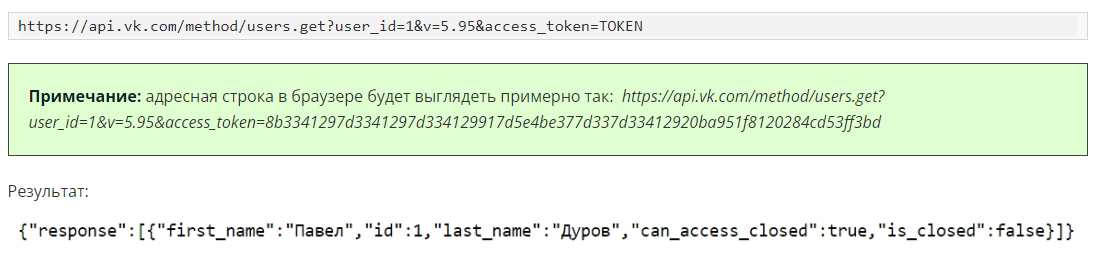

### Итак, мы сделали **GET-запрос к API ВКонтакте**, который состоит из следующих элементов:

* **https://api.vk.com/method** — домен и URL запроса API; обычно не меняется;

* **users.get** — название метода, который отдаёт определённый отчёт, в нашем случае это метод для получения информации о пользователе;

* **user_id и v** — параметры запроса: идентификатор пользователя, о котором хотим получить информацию (в нашем примере мы запрашиваем информацию о первом пользователе), и номер версии API;

* **token** — токен, который выдаётся только пользователям, имеющим право просматривать определённые данные, например показания счётчиков Яндекс.Метрики вашего проекта; на все остальные запросы без корректного токена система отвечает отказом.

Если мы обратимся к документации метода users.get, то увидим, что в ней описано множество других параметров, которые можно получить о пользователе (дата рождения, пол, родной город и другие) — словом, всё то, что мы видим на странице пользователя в интерфейсе или приложении ВКонтакте (конечно, если пользователь их указал).

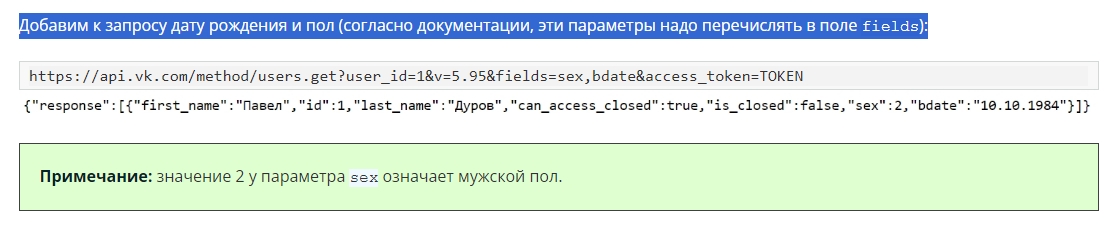

## Запрос к API из кода

Продолжаем пользоваться всё той же библиотекой requests.

In [7]:
import requests # Импортируем модуль requests
token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56' # Указываем свой сервисный токен
url = 'https://api.vk.com/method/users.get' # Указываем адрес страницы к которой делаем запрос
params = {'user_id': 1, 'v': 5.95, 'fields': 'sex,bdate', 'access_token': token, 'lang': 'ru'} # Перечисляем параметры нашего запроса в словаре params
response = requests.get(url, params=params) # Отправляем запрос
print(response.text) # Выводим текст ответа на экран

{"response":[{"id":1,"bdate":"10.10.1984","sex":2,"first_name":"Павел","last_name":"Дуров","can_access_closed":true,"is_closed":false}]}


* Мы получили строку в **JSON-формате**, которую можно преобразовать в словарь с помощью метода json(), после чего можно с лёгкостью обращаться к различным полям.

* Словари нагляднее выводить с помощью функции **pprint()**, которую мы уже использовали ранее:

In [8]:
from pprint import pprint # Импортируем функцию pprint()
pprint(response.json()) # Выводим содержимое словаря, содержащего ответ, на экран

{'response': [{'bdate': '10.10.1984',
               'can_access_closed': True,
               'first_name': 'Павел',
               'id': 1,
               'is_closed': False,
               'last_name': 'Дуров',
               'sex': 2}]}


##### Как вы видите, по **ключу response** мы можем получить **список**, в котором хранятся **словари**, содержащие информацию о запрошенных нами пользователях. Мы запросили информацию лишь об одном из них, поэтому список содержит только один элемент. Извлечём его:

In [12]:
user = response.json()['response'][0] # Извлекаем из словаря по ключу response информацию о первом пользователе
print(user['first_name']) # Выводим дату рождения первого пользователя на экран

Павел


### **Метод users.get()** позволяет запрашивать информацию о **множестве (до 1 000)** пользователей одновременно. Для этого нужно использовать параметр **user_ids** и передавать **id** через запятую в строковом формате. Например, чтобы получить информацию о пользователях с **id=1, id=2, id=3**, необходимо передать значение параметра **user_ids='1,2,3'**.

In [13]:
import requests

url = 'https://api.vk.com/method/users.get'
token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56'
ids = ",".join(map(str, range(1, 501))) # Формируем строку, содержащую информацию о поле id первых трёх пользователей
params = {'user_ids': ids, 'v': 5.95, 'fields': 'sex,bdate', 'access_token': token, 'lang': 'ru'} # Формируем строку параметров
response_vk = requests.get(url, params=params).json()
pprint(response_vk) # Посылаем запрос, полученный ответ в формате JSON-строки преобразуем в словарь и выводим на экран его содержимое, используя функцию pprint()

{'response': [{'bdate': '10.10.1984',
               'can_access_closed': True,
               'first_name': 'Павел',
               'id': 1,
               'is_closed': False,
               'last_name': 'Дуров',
               'sex': 2},
              {'bdate': '14.2',
               'can_access_closed': False,
               'first_name': 'Александра',
               'id': 2,
               'is_closed': True,
               'last_name': 'Владимирова',
               'sex': 1},
              {'can_access_closed': True,
               'deactivated': 'deleted',
               'first_name': 'DELETED',
               'id': 3,
               'is_closed': False,
               'last_name': '',
               'sex': 0},
              {'can_access_closed': True,
               'deactivated': 'deleted',
               'first_name': 'DELETED',
               'id': 4,
               'is_closed': False,
               'last_name': '',
               'sex': 0},
              {'bdate': '18.11',
  

In [10]:
# ЗАДАЧА
# Используя API, определите долю женщин (sex=1) среди пользователей с id от 1 до 500. 
# Иногда будут попадаться пользователи, у которых пол не указан (sex=0), — таких пользователей не нужно учитывать в общем числе.
# В ответе укажите число, округлив до двух знаков после точки-разделителя, например, 0.55.

# ВАРИАНТ 1.

count_miss = count_men = 0

for element in response_vk['response']:
    if element['sex'] == 1:
        count_miss += 1
    if element ['sex']  == 2:
        count_men += 1
    else:
        continue   
        
x = round(count_miss / (count_miss+count_men),2)
print (x)
    

0.49


In [ ]:
# ЭТАЛОННОЕ РЕШЕНИЕ

import requests
#token = '...'
url = 'https://api.vk.com/method/users.get'
ids = ",".join(map(str, range(1, 501)))
params = {'user_ids': ids, 'v': 5.95, 'fields': 'sex,bdate', 'access_token': token, 'lang': 'ru'}
response = requests.get(url, params=params).json()['response'] # !!!!!!!!!!   ЗДЕСЬ разница   !!!!!!!!!!!!!!!!!  

men=women=0

for elem in response:
    if elem['sex'] == 2:
        men+=1
    elif elem['sex'] == 1:
        women+=1
    else:
        continue
print(round(women/(men+women),2))

### **Сбор информации из групп**

##### Теперь мы научимся считать произвольные метрики групп, собирая данные из **API** и работая с **двумя ограничениями**, которые свойственны практически всем системам:

* ограничение на количество **вызовов** в единицу времени;
* ограничение на количество выгружаемых **строк** за один запрос.

##### **Согласно документации**, обязательным параметром данного метода является **group_id** — идентификатор, или **короткое имя**, группы. В нашем случае это **vk: https://vk.com/vk**. Протестируем, как работает метод в самом простом случае, — получим **id** участников группы:

##### Давайте рассмотрим, как работать с этими ограничениями на примере выгрузки списка пользователей группы **https://vk.com/vk** социальной сети **ВКонтакте**.

In [24]:
import requests # Импортируем модуль requests

token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56' # Указываем свой сервисный токен
url = 'https://api.vk.com/method/groups.getMembers' # Указываем адрес обращения
params = {'group_id': 'vk', 'v': 5.95, 'access_token': token} # Формируем строку параметров

response = requests.get(url, params = params) # Посылаем запрос
data = response.json() # Ответ сохраняем в переменной data в формате словаря

print(data) # Выводим содержимое переменной data на экран (отображён фрагмент)

{'response': {'count': 18414739, 'items': [5, 6, 14, 19, 34, 47, 54, 79, 88, 102, 106, 163, 166, 177, 198, 212, 219, 243, 254, 279, 296, 302, 345, 353, 403, 404, 421, 431, 433, 450, 467, 485, 510, 513, 550, 619, 640, 690, 696, 702, 721, 741, 804, 809, 832, 834, 847, 900, 905, 907, 914, 921, 943, 952, 958, 966, 976, 997, 1000, 1018, 1023, 1032, 1033, 1039, 1058, 1059, 1091, 1097, 1127, 1128, 1131, 1139, 1140, 1159, 1174, 1179, 1185, 1188, 1213, 1245, 1270, 1273, 1301, 1322, 1333, 1334, 1351, 1381, 1386, 1388, 1406, 1411, 1418, 1432, 1490, 1494, 1503, 1531, 1550, 1568, 1570, 1575, 1586, 1590, 1593, 1598, 1610, 1615, 1632, 1634, 1650, 1665, 1674, 1679, 1690, 1697, 1698, 1699, 1700, 1721, 1740, 1745, 1754, 1796, 1814, 1820, 1822, 1829, 1834, 1839, 1840, 1843, 1852, 1858, 1863, 1869, 1887, 1889, 1917, 1925, 1936, 1941, 1943, 1946, 1947, 1955, 1969, 2019, 2022, 2028, 2030, 2042, 2050, 2051, 2052, 2059, 2069, 2077, 2103, 2136, 2150, 2195, 2201, 2222, 2230, 2236, 2273, 2281, 2296, 2298, 2306, 

##### **ВЫВОДЫ:** По ключу **count** мы можем получить общее число участников группы, а список по ключу **items** хранит их id.

In [25]:
print(len(data['response']['items'])) # Выводим на экран количество элементов словаря

1000


##### **Вывод:** Мы видим, что всего пользователей в группе больше 18 миллионов, а получили мы только первую тысячу пользователей группы. По информации, указанной в документации о параметре count, это максимум, который может отдать API за один раз.

##### Для получения следующей тысячи пользователей можно воспользоваться параметром **offset** (с англ. смещение), который передвинет начало отсчёта. Для выгрузки всех пользователей группы будем в цикле выгружать по 1000 пользователей (count будет всегда равен 1000), увеличивая смещение offset на величину count.

##### Для тренировки напишем цикл выгрузки первых 20 пользователей со значением count=5. Иными словами, мы будем выгружать по пять пользователей за запрос до тех пор, пока не получим информацию о 20 пользователях.

##### Давайте выведем на экран первые 20 пользователей из нашей первой попытки получить информацию о 1000 пользователей, чтобы мы могли сверить результат выгрузки из 20 пользователей:

In [21]:
users_for_checking = data['response']['items'][:20] # Загружаем в переменную информацию об id первых 20 пользователей в виде списка
print(users_for_checking) # Выводим перечень id первых 20 пользователей

[5, 6, 14, 19, 34, 47, 54, 79, 88, 102, 106, 163, 166, 177, 198, 212, 219, 243, 254, 279]


### Теперь используем **count** и **offset**, чтобы получить те же **id** по пять за раз:

In [ ]:
import requests # Импортируем модуль requests

token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56' # Указываем свой сервисный токен
url = 'https://api.vk.com/method/groups.getMembers' # Указываем адрес обращения
count = 5 
offset = 0 
user_ids = [] 
max_count = 20
 
while offset < max_count: 
    # Будем выгружать по count=5 пользователей, 
    # начиная с того места, где закончили на предыдущей итерации (offset) 
    print('Выгружаю {} пользователей с offset = {}'.format(count, offset))   
    params = {'group_id': 'vk', 'v': 5.95, 'count': count, 'offset': offset, 'access_token': token} 
    response = requests.get(url, params = params) 
    data = response.json() 
    user_ids += data['response']['items'] # можно и просто - user_ids.append(data['response']['items']) - но тогда в ответе будет список из 4-х списков
    # Увеличиваем смещение на количество строк, которое мы уже выгрузили 
    offset += count
     
print(user_ids) 

Выгружаю 5 пользователей с offset = 0
Выгружаю 5 пользователей с offset = 5
Выгружаю 5 пользователей с offset = 10
Выгружаю 5 пользователей с offset = 15
[5, 6, 14, 19, 34, 47, 54, 79, 88, 102, 106, 163, 166, 177, 198, 212, 219, 243, 254, 259]


##### Сравним списки, полученные двумя способами:

In [23]:
print(user_ids == users_for_checking) 

True


##### **Так как результат сравнения — True**, списки идентичны. Значит, второй способ работает корректно. Теперь мы можем получить данные обо всех пользователях, выставив **count = 1000** и **max_count = data['response']['count']**.

## **Ограничение по частоте запросов**

* → В **API** часто добавляют ограничение по частоте запросов, чтобы отдельно взятые пользователи слишком сильно не перегружали сервер. Подобное ограничение есть и у ВКонтакте — в документации указано, что можно делать не более **трёх запросов в секунду**.

### Воспользуемся библиотекой **time** и методом **sleep**, с помощью которого мы можем добавить паузу, например в **0.5** секунд, после каждого запроса:

In [39]:
import requests # Импортируем модуль requests
import time # Импортируем модуль time

token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56' # Указываем свой сервисный токен
url = 'https://api.vk.com/method/groups.getMembers' # Указываем адрес страницы, к которой делаем запрос
count = 1000 
offset = 0  
user_ids = []
  
while offset < 7000: 
    params = {'group_id': 'vk', 'v': 5.95, 'count': count, 'offset': offset, 'access_token': token} 
    response = requests.get(url, params = params) 
    data = response.json() 
    user_ids += data['response']['items'] 
    offset += count 
    
    print('Ожидаю 0.5 секунды...') 
    time.sleep(0.5)
     
print('Цикл завершен, offset =',offset)
print ('----------------------------')
print (user_ids) 

Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Ожидаю 0.5 секунды...
Цикл завершен, offset = 7000
----------------------------
[5, 6, 14, 19, 34, 47, 54, 79, 88, 102, 106, 163, 166, 177, 198, 212, 219, 243, 254, 279, 296, 302, 345, 353, 403, 404, 421, 431, 433, 450, 467, 485, 510, 513, 550, 619, 640, 690, 696, 702, 721, 741, 804, 809, 832, 834, 847, 900, 905, 907, 914, 921, 943, 952, 958, 966, 976, 997, 1000, 1018, 1023, 1032, 1033, 1039, 1058, 1059, 1091, 1097, 1127, 1128, 1131, 1139, 1140, 1159, 1174, 1179, 1185, 1188, 1213, 1245, 1270, 1273, 1301, 1322, 1333, 1334, 1351, 1381, 1386, 1388, 1406, 1411, 1418, 1432, 1490, 1494, 1503, 1531, 1550, 1568, 1570, 1575, 1586, 1590, 1593, 1598, 1610, 1615, 1632, 1634, 1650, 1665, 1674, 1679, 1690, 1697, 1698, 1699, 1700, 1721, 1740, 1745, 1754, 1796, 1814, 1820, 1822, 1829, 1834, 1839, 1840, 1843, 1852, 1858, 1863, 1869, 1887, 1889, 1917, 1925, 1936, 1941, 1943

## **Лайки, репосты и комментарии**

### Для получения информации о сообщениях на стене в API ВКонтакте предусмотрен метод **wall.get**.

In [41]:
import requests # Импортируем модуль requests
from pprint import pprint # Импортируем функцию pprint()

token = '42f75d8e42f75d8e42f75d8efc41d8cadd442f742f75d8e2af61ee836c9ad13cbf48c56' # Указываем свой сервисный токен
url = 'https://api.vk.com/method/wall.get' # Указываем адрес страницы, к которой делаем запрос
params = {'domain': 'vk', 'filter': 'owner', 'count': 100, 'offset': 0, 'access_token': token, 'v': 5.95} 
response = requests.get(url, params = params)
 
pprint(response.json()) 

{'response': {'count': 822,
              'items': [{'attachments': [{'photo': {'access_key': 'a94d3368e3823de58f',
                                                    'album_id': -7,
                                                    'date': 1744971457,
                                                    'id': 457362780,
                                                    'orig_photo': {'height': 1080,
                                                                   'type': 'base',
                                                                   'url': 'https://sun9-38.userapi.com/s/v1/ig2/E8GMf7kB_hqqgrUMwbqcwbfw5qk7LZ56O3kWUMfnQBUGGSb5KeFAu7d9y61DiTwuEXY3koi0V_Z4o2vMkQ7yYIhh.jpg?quality=95&as=32x32,48x48,72x72,108x108,160x160,240x240,360x360,480x480,540x540,640x640,720x720,1080x1080&from=bu',
                                                                   'width': 1080},
                                                    'owner_id': -22822305,
                              

In [34]:
# Посмотрим на количество результатов:

pprint(len(response.json()['response']['items'])) 

100


In [37]:
# Посмотрим на информацию об отдельном сообщении:

response.json()['response']['items'][0] 

{'inner_type': 'wall_wallpost',
 'comments': {'count': 457},
 'marked_as_ads': 0,
 'hash': 'pFBmdiV56lKjoZQdgg',
 'type': 'post',
 'push_subscription': {'is_subscribed': False},
 'attachments': [{'type': 'photo',
   'photo': {'album_id': -7,
    'date': 1744971457,
    'id': 457362780,
    'owner_id': -22822305,
    'access_key': 'a94d3368e3823de58f',
    'post_id': 1600896,
    'sizes': [{'height': 75,
      'type': 's',
      'width': 75,
      'url': 'https://sun9-38.userapi.com/s/v1/ig2/E8GMf7kB_hqqgrUMwbqcwbfw5qk7LZ56O3kWUMfnQBUGGSb5KeFAu7d9y61DiTwuEXY3koi0V_Z4o2vMkQ7yYIhh.jpg?quality=95&as=32x32,48x48,72x72,108x108,160x160,240x240,360x360,480x480,540x540,640x640,720x720,1080x1080&from=bu&cs=75x75'},
     {'height': 130,
      'type': 'm',
      'width': 130,
      'url': 'https://sun9-38.userapi.com/s/v1/ig2/E8GMf7kB_hqqgrUMwbqcwbfw5qk7LZ56O3kWUMfnQBUGGSb5KeFAu7d9y61DiTwuEXY3koi0V_Z4o2vMkQ7yYIhh.jpg?quality=95&as=32x32,48x48,72x72,108x108,160x160,240x240,360x360,480x480,540x540,6

##### **ВЫВОДЫ:** В полях **comments, likes и reposts** содержится статистика по взаимодействию с сообщением пользователей (на момент получения информации) — число **комментариев, лайков и репостов**.

In [42]:
# ЗАДАЧА

# Давайте соберём итоговую статистику для последних десяти непустых сообщений в словарь stats. 
# В качестве ключа будем использовать начало сообщения (если начало сообщения пустое, то информацию о таком сообщении проигнорируем), 
# в качестве значения — список с тремя интересующими нас метриками и временем публикации (комментарии, лайки, репосты, дата публикации):

stats = {} 
count_post = 0 # Счётчик «непустых» сообщений

for record in response.json()['response']['items'][:]:
    title = record['text'][:30] 
    if title: 
        stats[title] = [record['comments']['count'], record['likes']['count'], record['reposts']['count'], record['date']] 
        count_post += 1 
    if count_post < 10: 
        continue 
    else: 
        break
     
pprint(stats)

{'А вы знали, что ВКонтакте можн': [460, 447, 90, 1744974013],
 'Будьте спокойны за то, что смо': [416, 426, 45, 1744633811],
 'В VK Знакомствах теперь можно ': [179, 326, 35, 1744287676],
 'В метавселенной Fortnite появи': [579, 516, 188, 1743435248],
 'Новые возможности для коллабор': [520, 636, 274, 1743408630],
 'Подарки каждый день и розыгрыш': [233, 474, 47, 1743778202],
 'Поздравляем Александра Овечкин': [1182, 12646, 564, 1743962892],
 'Празднуем рекорд Овечкина всей': [908, 6027, 243, 1744023178],
 'Хьюстон, у нас премьера! 🛰 Ко ': [283, 387, 44, 1744372545],
 'Что можно купить ВКонтакте? Ди': [243, 418, 36, 1744125661]}


## **Другие API**

##### Вы познакомились с интерфейсами прикладного программирования — **API** (на примере API социальной сети ВКонтакте).

**API** для разработчиков предоставляют и многие другие платформы. Вот список, пожалуй, самых популярных из них:

* Google Maps API
* YouTube API
* Twitter API
* Facebook API

Вы также можете воспользоваться интернет-поиском, указав в поисковой строке, например, **«курсы валют API»** или **«прогноз погоды api»**, — среди первых результатов выдачи чаще всего с лёгкостью можно найти ссылки на необходимый функционал.

## **Скрипты**

* В случае когда вам нужен **автоматический запуск скриптов**, или, как часто его называют программисты, запуск **по крону** — от английского акронима **Cron** (англ. Command Run ON) — названия системы для автоматического запуска программ и скриптов на сервере в определённое время.

### Как настроить автоматический запуск

* Исполняемый по расписанию код часто называют **задачей** (англ. task). Для планирования задач в Python есть несколько библиотек, среди которых — популярный и простой в использовании модуль **schedule** (c англ. расписание). Он позволяет запускать код как с определённым интервалом, так и в заданное время.

In [ ]:
# Модуль schedule не входит в стандартную библиотеку Python, поэтому его необходимо установить:

# Устанавливаем библиотеку schedule
#pip install schedule 

In [1]:
# 1.

# Импортируем модуль schedule
import schedule

In [ ]:
# 2.

# Рассмотрим вариант автоматического запуска простой функции, которая выводит на экран короткое сообщение:

def task(): 
    print('Hello! I am a task!') 
    return

<function __main__.task()>

##### **ЗАДАЧА**

* Предположим, что мы хотим, чтобы функция запускалась через определённые интервалы времени, а именно **каждые 15 минут**.
* Для запуска задачи через определённые интервалы времени в модуле **schedule** используется метод **every()**, который получает в качестве единственного аргумента число, указывающее, как часто следует запускать код.
* Далее вызывается метод, определяющий единицы измерения промежутков времени, через которые будет выполняться функция. В нашем примере это минуты. Вот как будет выглядеть итоговый код:

In [ ]:
# 3.

schedule.every(15).minutes.do(task)

In [ ]:
# Если бы мы хотели запускать задачу, например, каждый час, то могли бы написать:

schedule.every(1).hour.do(task)

# schedule.every(60).seconds.do(task)

#### Далее запускаем наш менеджер расписания **(schedule)**. Для этого надо создать **бесконечный цикл**. Да-да, именно так, ведь скрипт должен выполняться постоянно, чтобы постоянно проверять, не пришло ли время снова выполнить задачу.

* Внутри цикла мы будем вызывать особый метод **run_pending()** для объекта **schedule**, который будет проверять, нет ли задачи, которую пора выполнить.
* После вызова метода **run_pending()** нужно будет сделать небольшую паузу, после которой можно будет снова проверять, не пришло ли время для выполнения какой-либо функции.

In [ ]:
# 4.

# Для создания паузы мы будем использовать метод sleep из модуля time, поэтому наш код начнётся с импорта данного модуля:

import time 
while True: 
    schedule.run_pending() 
    time.sleep(1) 

In [ ]:
# 5.

# Вот какой код в итоге получился:

import schedule

def task(): 
    print('Hello! I am a task!')
    return 
    
schedule.every(15).minutes.do(task)

import time 
while True: 
    schedule.run_pending() 
    time.sleep(1)

### **Вывод:** Этот код будет **каждую секунду** проверять, не надо ли выполнить какую-то задачу, и **раз в 15 минут** будет выводить на экран фразу: **"Hello! I am a task!"** Вывод сообщения будет повторяться до тех пор, пока вы не остановите выполнение скрипта.